* Alumno: Juan Asimbaya

# Custom YOLO Object Detection with RoboFlow

### **Step 1: Install Required Dependencies**

In [1]:
# Así funcionó:
%pip install numpy==1.26.4
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
%pip install ultralytics
%pip install opencv-python-headless
%pip install matplotlib
%pip install -q pandas seaborn scikit-learn tensorflow-cpu==2.18.0 tensorboard
%pip install roboflow


  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached torchvision-0.29.0%2Bcpu-cp310-cp310-win_amd64.whl.metadata (5.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached pillow-12.3.0-cp310-cp310-win_amd64.whl.metadata (9.3 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/124.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/124.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/124.0 MB 4.2 MB/s eta 0:00:30
    --------------------------------------- 2.6/124.0 MB 5.2 MB/s eta 0:00:24
   - -----------------------------

### **Step 2: Import Required Libraries**

In [2]:
from roboflow import Roboflow
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

### **Step 3: Set Up RoboFlow Account**

1. Go to RoboFlow and create a free account
2. Create a new project and select "Object Detection" as project type
3. Choose "YOLOv26" as the model format

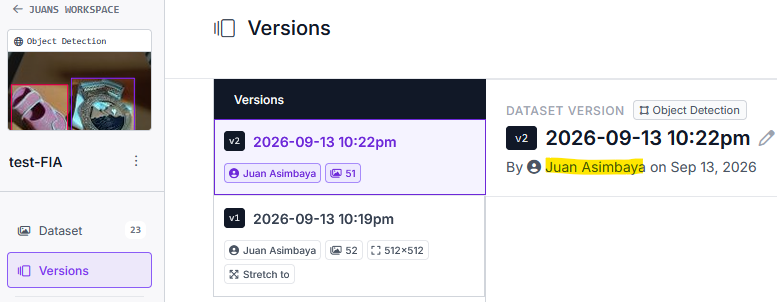

### **Step 4: Upload and Annotate Your Images**

#### Using RoboFlow Web Interface:

1. Click "Upload" to add your images
2. Use the annotation tool to draw bounding boxes around objects
3. Assign the correct class labels to each bounding box
4. Apply preprocessing and augmentation as needed

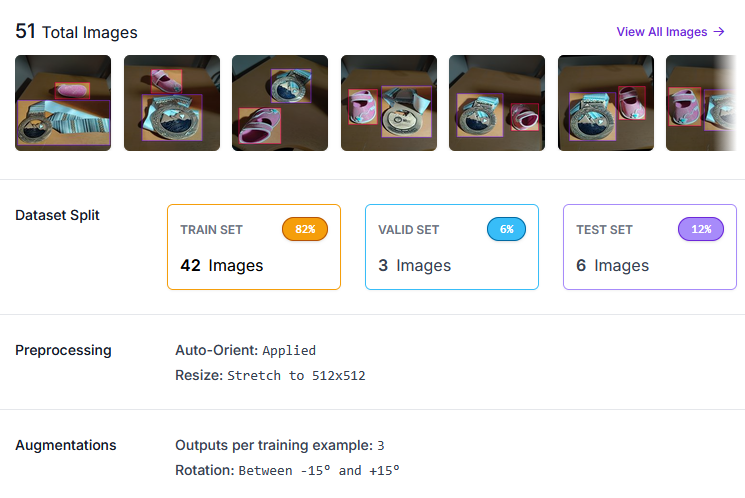

### **Step 5. Download your Custom your Dataset**

1. In RoboFlow, go to your project dashboard
2. Click "Generate" to create a dataset version
3. Apply any desired augmentations
4. Click "Export" and select "YOLOv**x**" format (**x** the version you are using)
5. Copy the download code

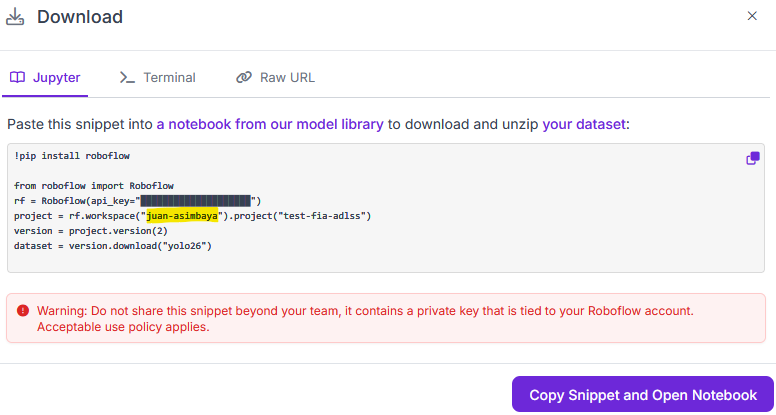

In [3]:
# Initialize RoboFlow (you'll need your API key)

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vMnnGl1vxt0n7h0Kguzu")
project = rf.workspace("juan-asimbaya").project("final_exam_fia")
version = project.version(2)
dataset = version.download("yolo26")
                      

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Final_Exam_FIA-2 in yolo26:: 100%|██████████| 245/245 [00:00<00:00, 300.05it/s]


### **Step 6: Train Your Custom YOLO Model**

In [4]:
# Load the YOLO model with custom configuration
model = YOLO('yolo26n.pt')  # Using nano version as base

# Train the model on your custom dataset
results = model.train(
    data=f'{dataset.location}/data.yaml',  # Path to dataset config
    epochs=20,  # Number of training epochs
    imgsz=640,  # Image size
    batch=8,   # Batch size
    name='custom_yolo_model'  # Name for the training run
)

Ultralytics 8.4.155  Python-3.10.11 torch-2.14.0+cpu CPU (Intel Core Ultra 7 155U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Final_Exam_FIA-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0

### **Step 7: Evaluate Your Model**

In [5]:
# Evaluate model performance
metrics = model.val()  # Validate the model
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")

# Show some validation results
!yolo task=detect mode=val model=runs/detect/custom_yolo_model/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.155  Python-3.10.11 torch-2.14.0+cpu CPU (Intel Core Ultra 7 155U)
YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 272.065.9 MB/s, size: 21.9 KB)
val: Scanning C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Final_Exam_FIA-2\valid\labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.5s
                   all         10         10      0.995          1      0.995      0.927
Speed: 1.9ms preprocess, 41.1ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\runs\detect\val
mAP50-95: 0.9267460317460318
mAP50: 0.995

    Arguments received: ['yolo', 'task=detect', 'mode=val', 'model=runs/detect/custom_yolo_model/weights/best.pt', 'data=c:\\Users\\j_asi\\D

Traceback (most recent call last):
  File "C:\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\j_asi\Documents\Maestria\.venv\Scripts\yolo.exe\__main__.py", line 5, in <module>
  File "c:\Users\j_asi\Documents\Maestria\.venv\lib\site-packages\ultralytics\cfg\__init__.py", line 1074, in entrypoint
    check_dict_alignment(full_args_dict, {a: ""})
  File "c:\Users\j_asi\Documents\Maestria\.venv\lib\site-packages\ultralytics\cfg\__init__.py", line 665, in check_dict_alignment
    raise SyntaxError(string) from e
SyntaxError: 'IA\ExamenFinal\Final_Exam_FIA-2/data.yaml' is not a valid YOLO argument. 



### **Step 8: Test Your Custom Model on an Image**


image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.15.38 (3).jpeg: 320x640 1 plate, 34.0ms
Speed: 1.0ms preprocess, 34.0ms inference, 1.0ms postprocess per image at shape (1, 3, 320, 640)


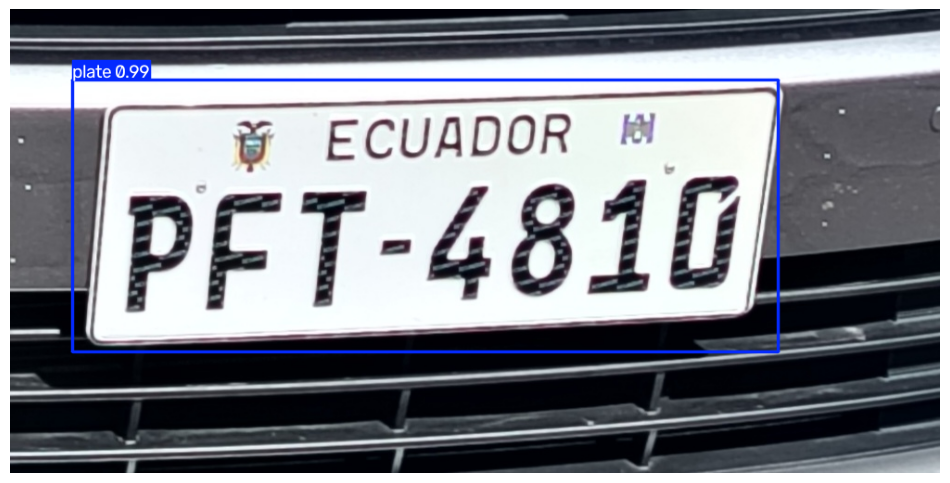


image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.15.38 (4).jpeg: 512x640 1 plate, 41.0ms
Speed: 2.1ms preprocess, 41.0ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 640)


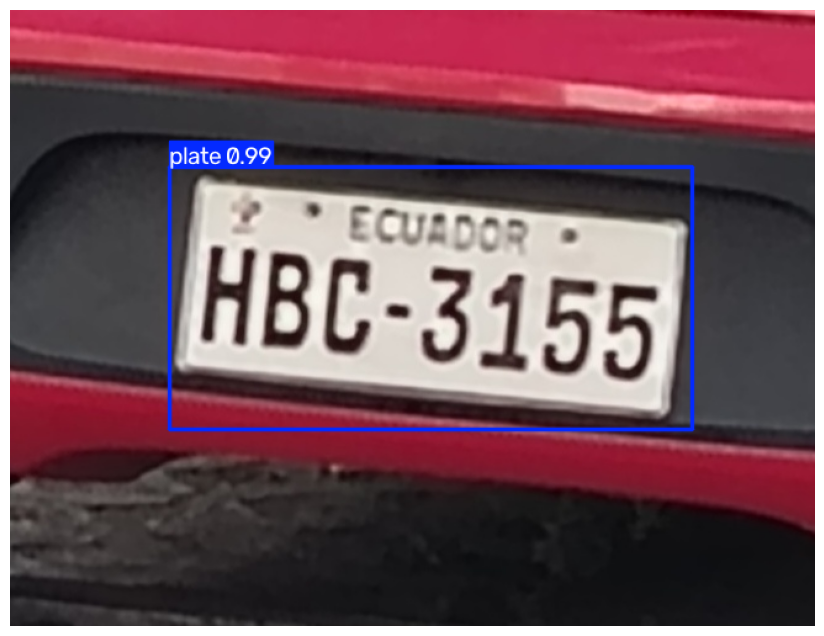


image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.15.38.jpeg: 192x640 1 plate, 31.3ms
Speed: 1.3ms preprocess, 31.3ms inference, 0.7ms postprocess per image at shape (1, 3, 192, 640)


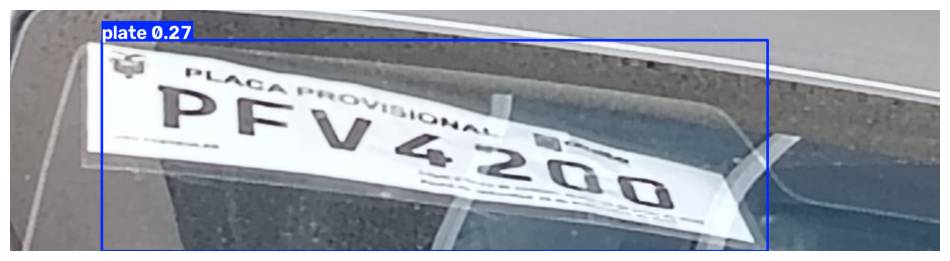


image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.15.39 (1).jpeg: 448x640 1 plate, 33.0ms
Speed: 1.3ms preprocess, 33.0ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)


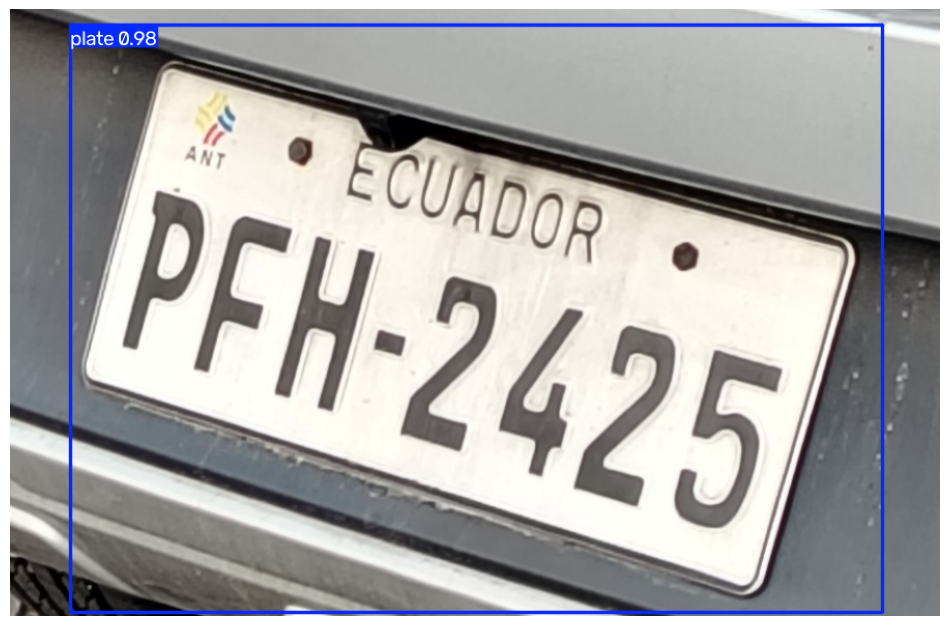


image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.15.39 (2).jpeg: 544x640 1 plate, 42.4ms
Speed: 2.3ms preprocess, 42.4ms inference, 0.9ms postprocess per image at shape (1, 3, 544, 640)


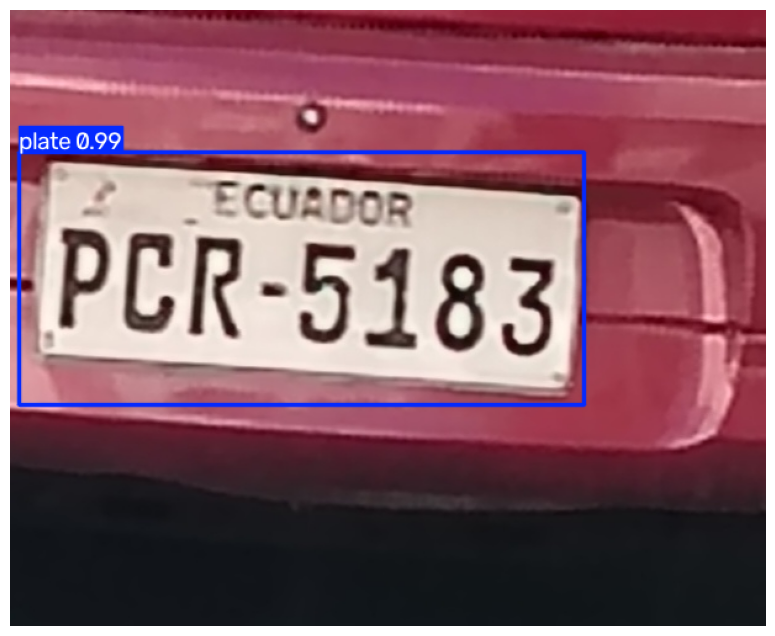


image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.15.39 (3).jpeg: 576x640 1 plate, 41.1ms
Speed: 2.2ms preprocess, 41.1ms inference, 1.0ms postprocess per image at shape (1, 3, 576, 640)


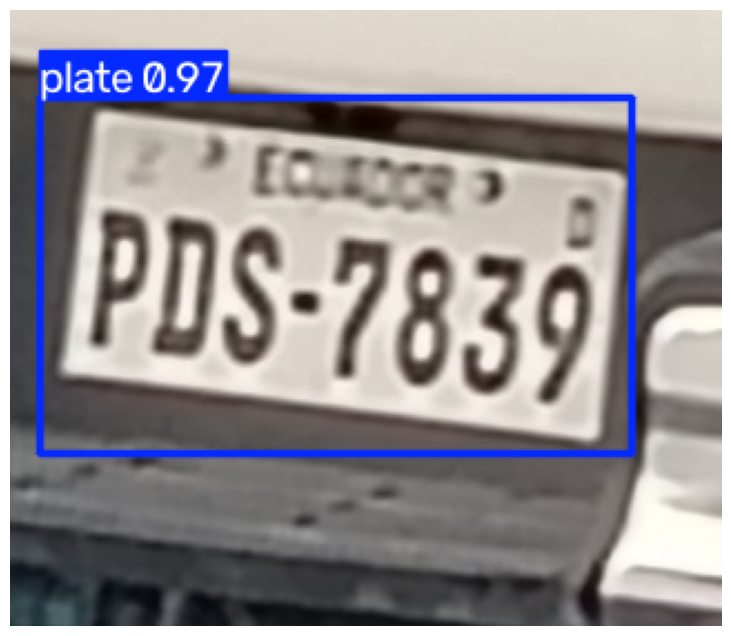


image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.15.39 (4).jpeg: 352x640 1 plate, 26.8ms
Speed: 1.2ms preprocess, 26.8ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)


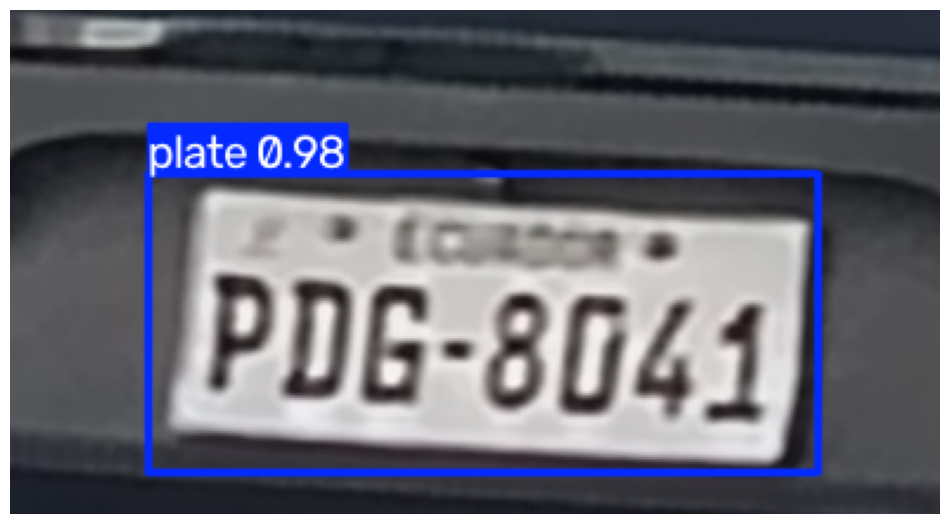


image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.15.39.jpeg: 384x640 1 plate, 36.3ms
Speed: 1.7ms preprocess, 36.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


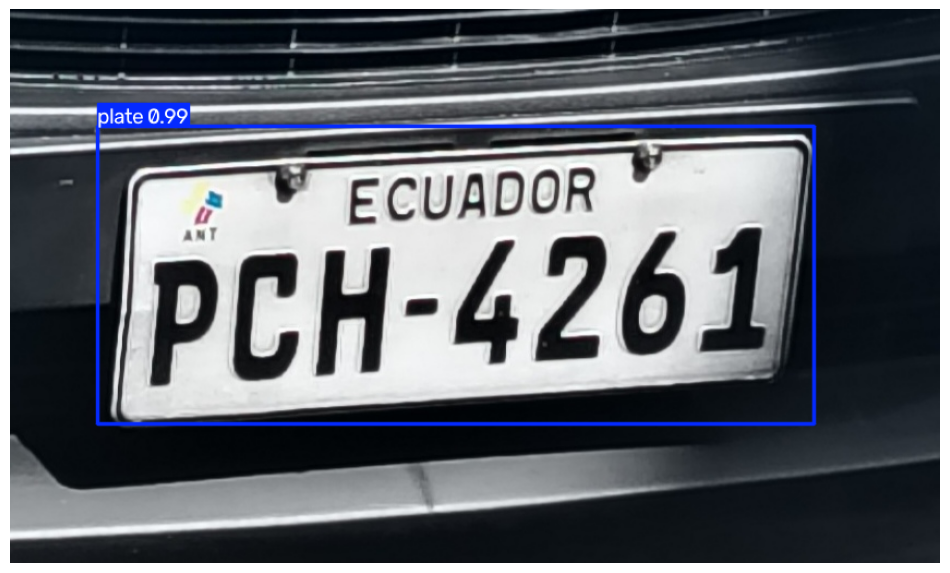

In [9]:
# Load your custom trained model
custom_model = YOLO(r'C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\runs\detect\custom_yolo_model\weights\best.pt')

val_dir = r"C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion"
for file in os.listdir(val_dir):
    # Test on a sample image
    mg_path = os.path.join(val_dir, file)
    results = custom_model.predict(mg_path, conf=0.25)

    # Display results
    %matplotlib inline
    for result in results:
        img = result.plot()  # Plot detections
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()

### **Step 9: Test Your Custom Model on Video**

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>

In [10]:
%pip install easyocr==1.7.1


   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   -------------- ------------------------- 1.0/2.9 MB 7.2 MB/s eta 0:00:01
   --------------------- ------------------ 1.6/2.9 MB 4.7 MB/s eta 0:00:01
   -------------------------------- ------- 2.4/2.9 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 4.3 MB/s  0:00:00
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.8 MB 8.4 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.8 MB 6.4 MB/s eta 0:00:02
   --------- ------------------------------ 3.1/12.8 MB 5.8 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.8 MB 5.5 MB/s eta 0:00:02
   ----------------- ---------------------- 5.5/12.8 MB 5.5 MB/s eta 0:00:02
   --------------------- ------------------ 6.8/12.8 MB 5.6 MB/s eta 0:00:02
   ------------------------- -------------- 8.1/12.8 MB 5.7 MB/s eta 0:00:01
   -----------------

#### Código de integración YOLO + EasyOCR

In [11]:
import os
import cv2
import numpy as np
import re
from ultralytics import YOLO
import easyocr

# Cargar modelo YOLO entrenado
custom_model = YOLO(r'C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\runs\detect\custom_yolo_model\weights\best.pt')

# Inicializar OCR
reader = easyocr.Reader(['en'], gpu=False)  # gpu=False porque trabajas en CPU

# Función para extraer texto de la placa
def extract_plate_text(plate_crop):
    # Recorte inferior para evitar "ECUADOR" y "ANT"
    h = plate_crop.shape[0]
    plate_crop = plate_crop[int(h*0.35):, :]

    # Preprocesamiento
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # OCR
    ocr_result = reader.readtext(thresh)

    # Filtrar por patrón de placa ecuatoriana (3 letras + 4 números)
    for _, text, _ in ocr_result:
        text = text.upper().replace(" ", "")
        if re.match(r'^[A-Z]{3}-?\d{4}$', text):
            return text
    return None

# Carpeta con imágenes de prueba
val_dir = r"C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion"

for filename in os.listdir(val_dir):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(val_dir, filename)

        # Leer imagen
        img = cv2.imread(img_path)

        # Detectar placa con YOLO
        results = custom_model.predict(img_path)
        boxes = results[0].boxes.xyxy.cpu().numpy()

        if len(boxes) > 0:
            # Tomar la primera placa detectada
            x1, y1, x2, y2 = boxes[0]
            plate_crop = img[int(y1):int(y2), int(x1):int(x2)]

            # Extraer texto con función personalizada
            plate_text = extract_plate_text(plate_crop)

            if plate_text:
                print(f"Imagen: {filename} → Placa detectada: {plate_text}")
            else:
                print(f"Imagen: {filename} → No se pudo leer la placa.")
        else:
            print(f"Imagen: {filename} → No se detectó ninguna placa.")


Using CPU. Note: This module is much faster with a GPU.



image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-16 at 21.56.21 (2).jpeg: 544x640 1 plate, 48.9ms
Speed: 3.1ms preprocess, 48.9ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 640)
Imagen: WhatsApp Image 2026-09-16 at 21.56.21 (2).jpeg → No se pudo leer la placa.

image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.05.39.jpeg: 416x640 1 plate, 56.7ms
Speed: 1.8ms preprocess, 56.7ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 640)
Imagen: WhatsApp Image 2026-09-18 at 09.05.39.jpeg → No se pudo leer la placa.

image 1/1 C:\Users\j_asi\Documents\Maestria\Fundamentos IA\ExamenFinal\Validacion\WhatsApp Image 2026-09-18 at 09.15.38 (3).jpeg: 320x640 1 plate, 58.3ms
Speed: 1.4ms preprocess, 58.3ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 640)
Imagen: WhatsApp Image 2026-09-18 at 09.15.38 (3).jpeg → Placa detectada: PFT-4810

im